In [3]:
import yfinance as yf
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
stocks = ["AMZN", "MSFT", "GOOG"]  # List of stock tickers
#start = dt.datetime.today() - dt.timedelta(360) # 30 days ago
#end = dt.datetime.today()

ohlcv_data = {}  # Dictionary to hold OHLCV data. Key-Value pair: Ticker-DataFrame

# get closing prices for each stock
for ticker in stocks:
    temp = yf.download(ticker, period="1y", interval="1d")
    temp.dropna(how="any", inplace=True) # type: ignore
    ohlcv_data[ticker] = temp


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


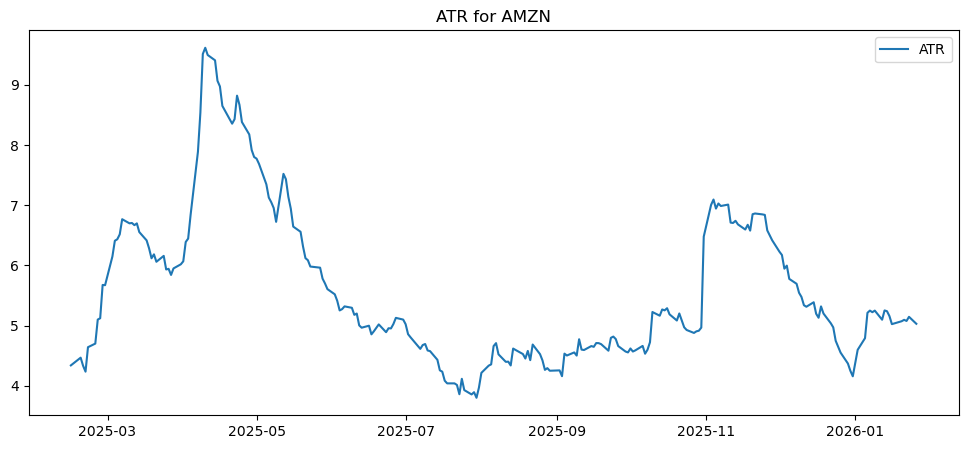

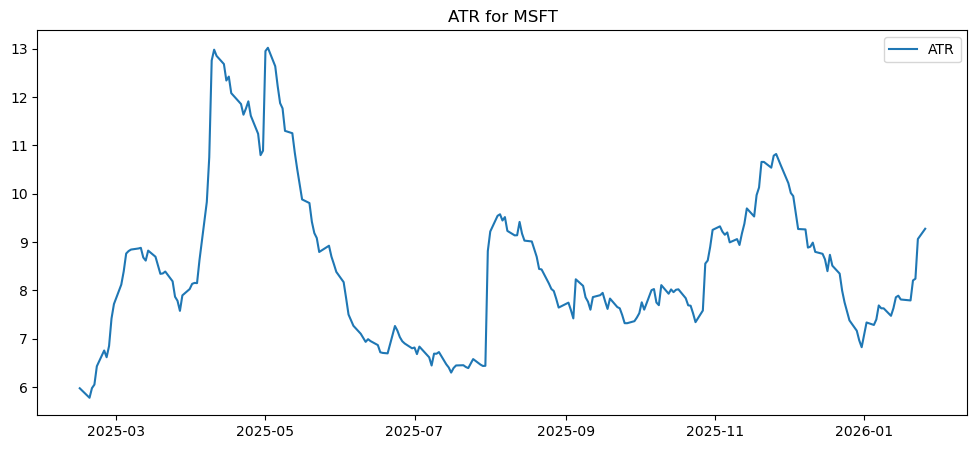

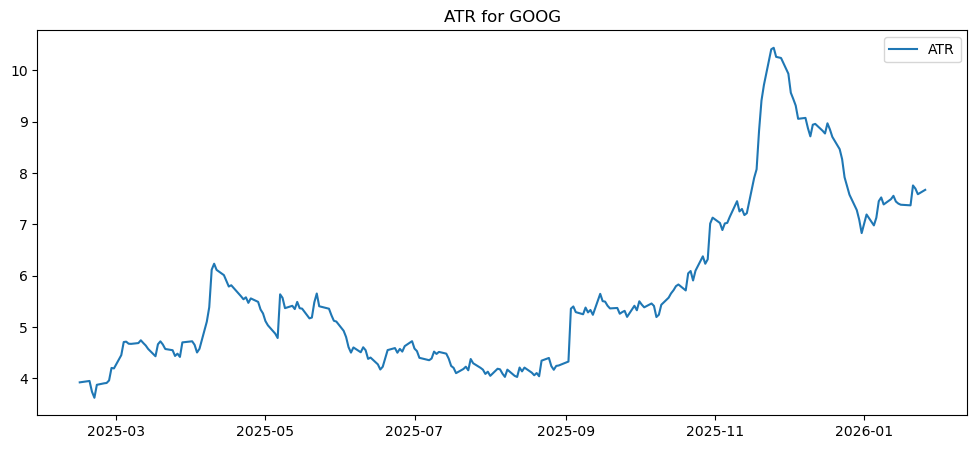

In [5]:
# atr
# i forgot why its useful
def atr(DF, n=14):
    df = DF.copy()

    df["H-L"] = df["High"] - df["Low"]
    df["H-PC"] = df["High"] - df["Close"].shift(1)
    df["L-PC"] = df["Low"] - df["Close"].shift(1)

    # max along the rows between all three gives true range
    df["TR"] = df[["H-L", "H-PC", "L-PC"]].max(axis=1, skipna=False)

    df["ATR"] = df["TR"].ewm(com=n, min_periods=n).mean()
    return df["ATR"]

for ticker in ohlcv_data:
    ohlcv_data[ticker]["ATR"] = atr(ohlcv_data[ticker])



for ticker in ohlcv_data:
    df = ohlcv_data[ticker]

    plt.figure(figsize=(12,5))
    plt.plot(df.index, df["ATR"], label="ATR")
    plt.title(f"ATR for {ticker}")
    plt.legend()
    plt.show()


